# Prueba técnica Insights
## Ejercicio 2 – Manejo de datos

**Santiago Osorio Gómez**  
**Cédula:** 1000.099.104  
**Fecha:** 12 de marzo de 2026

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# EJERCICIO 2.1
# Calculo del retorno esperado y la volatilidad esperada
# de los portafolios P1 y P2 a partir de la Matriz de Simulacion
# ============================================================

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    required_dirs = {"data", "docs", "notebooks", "outputs", "src"}

    for candidate in candidates:
        if candidate.exists():
            dir_names = {p.name for p in candidate.iterdir() if p.is_dir()}
            if required_dirs.issubset(dir_names):
                return candidate

    raise FileNotFoundError(
        "No se encontro la raiz del proyecto. "
        "Ejecuta este notebook dentro de ~/Documents/prueba_insights"
    )

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
DOCS_DIR = ROOT / "docs"
OUTPUTS_DIR = ROOT / "outputs"
EJ2_OUTPUT_DIR = OUTPUTS_DIR / "ejercicio_2"

DOCS_DIR.mkdir(parents=True, exist_ok=True)
EJ2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

excel_path = DATA_DIR / "prueba.xlsx"
if not excel_path.exists():
    raise FileNotFoundError(f"No existe el archivo: {excel_path}")

# ============================================================
# CARGA DE DATOS
# ============================================================

xls = pd.ExcelFile(excel_path)
required_sheets = {"Matriz de Simulacion", "P1", "P2"}

if not required_sheets.issubset(set(xls.sheet_names)):
    raise ValueError(
        f"El archivo no contiene las hojas esperadas. Hojas encontradas: {xls.sheet_names}"
    )

R_df = pd.read_excel(excel_path, sheet_name="Matriz de Simulacion")
P1_df = pd.read_excel(excel_path, sheet_name="P1")
P2_df = pd.read_excel(excel_path, sheet_name="P2")

# ============================================================
# VALIDACIONES
# ============================================================

assert R_df.shape == (30000, 55), f"Dimension inesperada para R: {R_df.shape}"
assert P1_df.shape == (1, 55), f"Dimension inesperada para P1: {P1_df.shape}"
assert P2_df.shape == (1, 55), f"Dimension inesperada para P2: {P2_df.shape}"

assert list(R_df.columns) == list(P1_df.columns), "Las columnas de P1 no coinciden con R"
assert list(R_df.columns) == list(P2_df.columns), "Las columnas de P2 no coinciden con R"

assert not R_df.isna().any().any(), "La Matriz de Simulacion contiene valores faltantes"
assert not P1_df.isna().any().any(), "P1 contiene valores faltantes"
assert not P2_df.isna().any().any(), "P2 contiene valores faltantes"

p1_sum = float(P1_df.sum(axis=1).iloc[0])
p2_sum = float(P2_df.sum(axis=1).iloc[0])

assert np.isclose(p1_sum, 1.0), f"La suma de pesos de P1 no es 1.0, sino {p1_sum}"
assert np.isclose(p2_sum, 1.0), f"La suma de pesos de P2 no es 1.0, sino {p2_sum}"

# ============================================================
# FORMULACION MATRICIAL
# ============================================================
# R: matriz [N x K] de retornos anuales simulados
# w: vector [K x 1] de pesos del portafolio
#
# Retorno por escenario:
# r_p = R @ w
#
# Retorno esperado:
# E[r_p] = mu @ w
#
# Varianza:
# Var(r_p) = w @ Sigma @ w
#
# Volatilidad:
# sigma_p = sqrt(w @ Sigma @ w)
# ============================================================

R = R_df.to_numpy(dtype=float)
w1 = P1_df.iloc[0].to_numpy(dtype=float)
w2 = P2_df.iloc[0].to_numpy(dtype=float)

mu = R.mean(axis=0)
Sigma = np.cov(R, rowvar=False, ddof=1)

def portfolio_stats(name: str, weights: np.ndarray, R: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> dict:
    portfolio_returns = R @ weights

    expected_return_direct = portfolio_returns.mean()
    expected_return_matrix = mu @ weights

    variance_matrix = weights @ Sigma @ weights
    volatility_matrix = np.sqrt(variance_matrix)

    volatility_direct = portfolio_returns.std(ddof=1)

    if not np.isclose(expected_return_direct, expected_return_matrix):
        raise ValueError(f"El retorno esperado no coincide en {name}")

    if not np.isclose(volatility_direct, volatility_matrix):
        raise ValueError(f"La volatilidad no coincide en {name}")

    return {
        "portfolio": name,
        "expected_return_decimal": float(expected_return_matrix),
        "expected_volatility_decimal": float(volatility_matrix),
        "expected_return_pct": float(expected_return_matrix * 100),
        "expected_volatility_pct": float(volatility_matrix * 100),
        "return_to_vol_ratio": float(expected_return_matrix / volatility_matrix),
    }

stats_p1 = portfolio_stats("P1", w1, R, mu, Sigma)
stats_p2 = portfolio_stats("P2", w2, R, mu, Sigma)

results = pd.DataFrame([stats_p1, stats_p2])

results_display = results.copy()
for col in [
    "expected_return_decimal",
    "expected_volatility_decimal",
    "expected_return_pct",
    "expected_volatility_pct",
    "return_to_vol_ratio",
]:
    results_display[col] = results_display[col].map(lambda x: round(x, 6))

print("EJERCICIO 2.1 - RESULTADOS")
print(results_display.to_string(index=False))

# ============================================================
# INTERPRETACION ECONOMICA BREVE
# ============================================================

preferred_portfolio = "P2" if stats_p2["return_to_vol_ratio"] > stats_p1["return_to_vol_ratio"] else "P1"

analysis_text = f"""
Ejercicio 2.1 - Retorno esperado y volatilidad esperada

Resultados:
- P1: retorno esperado = {stats_p1["expected_return_pct"]:.4f}% | volatilidad esperada = {stats_p1["expected_volatility_pct"]:.4f}%
- P2: retorno esperado = {stats_p2["expected_return_pct"]:.4f}% | volatilidad esperada = {stats_p2["expected_volatility_pct"]:.4f}%

Lectura economica:
- P1 ofrece el mayor retorno esperado, pero tambien el mayor nivel de riesgo.
- P2 ofrece un menor retorno esperado, pero con una volatilidad significativamente menor.
- En terminos de retorno por unidad de volatilidad, {preferred_portfolio} presenta la mejor relacion riesgo-retorno.

Conclusion:
- Para un perfil moderado o conservador, P2 luce mas defendible.
- Para un perfil agresivo, P1 puede ser adecuado si el objetivo principal es maximizar retorno esperado y existe tolerancia a una volatilidad anual cercana a 20.6%.
""".strip()

print("\n" + analysis_text)

# ============================================================
# MARKDOWN FINAL PARA ENTREGA
# ============================================================

markdown_final = f"""# Ejercicio 2.1 - Retorno esperado y volatilidad esperada
**Prueba tecnica Insights**  
**Santiago Osorio Gomez**

## Metodologia
Se utilizo la matriz de simulacion de retornos anuales de 30,000 escenarios para 55 activos, junto con los vectores de pesos de los portafolios P1 y P2.

La formulacion utilizada fue:
- retorno por escenario: `r_p = R @ P`
- retorno esperado: `E[r_p] = mu @ P`
- volatilidad esperada: `sigma_p = sqrt(P' @ Sigma @ P)`

Dado que la matriz contiene retornos anuales simulados, no se aplico anualizacion adicional.

## Resultados
- **P1:** retorno esperado = **{stats_p1["expected_return_pct"]:.4f}%** | volatilidad esperada = **{stats_p1["expected_volatility_pct"]:.4f}%**
- **P2:** retorno esperado = **{stats_p2["expected_return_pct"]:.4f}%** | volatilidad esperada = **{stats_p2["expected_volatility_pct"]:.4f}%**

## Interpretacion
P1 presenta el mayor retorno esperado, pero tambien una volatilidad sustancialmente mayor.  
P2 ofrece un retorno esperado menor, pero con un nivel de riesgo claramente mas contenido.

En consecuencia, para un perfil de riesgo moderado, **P2** parece la alternativa mas eficiente en terminos de retorno por unidad de riesgo.  
Si el mandato de inversion fuera agresivo y priorizara retorno esperado sobre estabilidad, **P1** seria la alternativa razonable.
"""

# ============================================================
# GUARDADO DE ARCHIVOS
# ============================================================

results.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_1_resultados_finales.csv", index=False)

with open(DOCS_DIR / "ejercicio_2_1_resultados_finales.md", "w", encoding="utf-8") as f:
    f.write(markdown_final)

with open(EJ2_OUTPUT_DIR / "ejercicio_2_1_analisis.txt", "w", encoding="utf-8") as f:
    f.write(analysis_text)

print("\nArchivos generados:")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_1_resultados_finales.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_1_analisis.txt'}")
print(f"- {DOCS_DIR / 'ejercicio_2_1_resultados_finales.md'}")

EJERCICIO 2.1 - RESULTADOS
portfolio  expected_return_decimal  expected_volatility_decimal  expected_return_pct  expected_volatility_pct  return_to_vol_ratio
       P1                 0.091191                     0.206253             9.119076                20.625331             0.442130
       P2                 0.058419                     0.101071             5.841911                10.107123             0.577999

Ejercicio 2.1 - Retorno esperado y volatilidad esperada

Resultados:
- P1: retorno esperado = 9.1191% | volatilidad esperada = 20.6253%
- P2: retorno esperado = 5.8419% | volatilidad esperada = 10.1071%

Lectura economica:
- P1 ofrece el mayor retorno esperado, pero tambien el mayor nivel de riesgo.
- P2 ofrece un menor retorno esperado, pero con una volatilidad significativamente menor.
- En terminos de retorno por unidad de volatilidad, P2 presenta la mejor relacion riesgo-retorno.

Conclusion:
- Para un perfil moderado o conservador, P2 luce mas defendible.
- Para un pe

# Ejercicio 2.1 - Retorno esperado y volatilidad esperada
**Prueba tecnica Insights**  
**Santiago Osorio Gomez**

## Metodologia
Se utilizo la matriz de simulacion de retornos anuales de 30,000 escenarios para 55 activos, junto con los vectores de pesos de los portafolios P1 y P2.

La formulacion utilizada fue:
- retorno por escenario: `r_p = R @ P`
- retorno esperado: `E[r_p] = mu @ P`
- volatilidad esperada: `sigma_p = sqrt(P' @ Sigma @ P)`

Dado que la matriz contiene retornos anuales simulados, no se aplico anualizacion adicional.

## Resultados
- **P1:** retorno esperado = **9.1191%** | volatilidad esperada = **20.6253%**
- **P2:** retorno esperado = **5.8419%** | volatilidad esperada = **10.1071%**

## Interpretacion
P1 presenta el mayor retorno esperado, pero tambien una volatilidad sustancialmente mayor.  
P2 ofrece un retorno esperado menor, pero con un nivel de riesgo claramente mas contenido.

En consecuencia, para un perfil de riesgo moderado, **P2** parece la alternativa mas eficiente en terminos de retorno por unidad de riesgo.  
Si el mandato de inversion fuera agresivo y priorizara retorno esperado sobre estabilidad, **P1** seria la alternativa razonable.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# EJERCICIO 2.2
# Computo numerico del retorno esperado y la volatilidad esperada
# de los portafolios P1 y P2 a partir de la matriz de simulacion
# ============================================================

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    required_dirs = {"data", "docs", "notebooks", "outputs", "src"}

    for candidate in candidates:
        if candidate.exists():
            dir_names = {p.name for p in candidate.iterdir() if p.is_dir()}
            if required_dirs.issubset(dir_names):
                return candidate

    raise FileNotFoundError(
        "No se encontro la raiz del proyecto. "
        "Ejecuta este notebook dentro de ~/Documents/prueba_insights"
    )

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
DOCS_DIR = ROOT / "docs"
OUTPUTS_DIR = ROOT / "outputs"
EJ2_OUTPUT_DIR = OUTPUTS_DIR / "ejercicio_2"

DOCS_DIR.mkdir(parents=True, exist_ok=True)
EJ2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

excel_path = DATA_DIR / "prueba.xlsx"
if not excel_path.exists():
    raise FileNotFoundError(f"No existe el archivo: {excel_path}")

# ============================================================
# CARGA DE DATOS
# ============================================================

R_df = pd.read_excel(excel_path, sheet_name="Matriz de Simulacion")
P1_df = pd.read_excel(excel_path, sheet_name="P1")
P2_df = pd.read_excel(excel_path, sheet_name="P2")

# ============================================================
# VALIDACIONES MINIMAS
# ============================================================

assert R_df.shape == (30000, 55), f"Dimension inesperada para R: {R_df.shape}"
assert P1_df.shape == (1, 55), f"Dimension inesperada para P1: {P1_df.shape}"
assert P2_df.shape == (1, 55), f"Dimension inesperada para P2: {P2_df.shape}"

assert list(R_df.columns) == list(P1_df.columns), "Las columnas de P1 no coinciden con R"
assert list(R_df.columns) == list(P2_df.columns), "Las columnas de P2 no coinciden con R"

assert not R_df.isna().any().any(), "La Matriz de Simulacion contiene valores faltantes"
assert not P1_df.isna().any().any(), "P1 contiene valores faltantes"
assert not P2_df.isna().any().any(), "P2 contiene valores faltantes"

assert np.isclose(float(P1_df.sum(axis=1).iloc[0]), 1.0), "P1 no suma 1"
assert np.isclose(float(P2_df.sum(axis=1).iloc[0]), 1.0), "P2 no suma 1"

# ============================================================
# FORMULACION Y COMPUTO
# ============================================================
# Retorno esperado:
# E[r_p] = mu @ w
#
# Volatilidad esperada:
# sigma_p = sqrt(w @ Sigma @ w)
#
# donde:
# - mu = vector de retornos esperados de los activos
# - Sigma = matriz de covarianzas de los activos
#
# Importante:
# Los retornos de la matriz son anuales, por lo que no se anualiza nuevamente.
# ============================================================

R = R_df.to_numpy(dtype=float)
w1 = P1_df.iloc[0].to_numpy(dtype=float)
w2 = P2_df.iloc[0].to_numpy(dtype=float)

mu = R.mean(axis=0)
Sigma = np.cov(R, rowvar=False, ddof=1)

def compute_portfolio_metrics(name: str, weights: np.ndarray) -> dict:
    portfolio_returns = R @ weights

    expected_return = float(mu @ weights)
    expected_volatility = float(np.sqrt(weights @ Sigma @ weights))

    expected_return_direct = float(portfolio_returns.mean())
    expected_volatility_direct = float(portfolio_returns.std(ddof=1))

    if not np.isclose(expected_return, expected_return_direct):
        raise ValueError(f"El retorno esperado no coincide para {name}")

    if not np.isclose(expected_volatility, expected_volatility_direct):
        raise ValueError(f"La volatilidad esperada no coincide para {name}")

    return {
        "portfolio": name,
        "expected_return_decimal": expected_return,
        "expected_volatility_decimal": expected_volatility,
        "expected_return_pct": expected_return * 100,
        "expected_volatility_pct": expected_volatility * 100,
    }

p1_metrics = compute_portfolio_metrics("P1", w1)
p2_metrics = compute_portfolio_metrics("P2", w2)

results = pd.DataFrame([p1_metrics, p2_metrics])

results_print = results.copy()
for col in [
    "expected_return_decimal",
    "expected_volatility_decimal",
    "expected_return_pct",
    "expected_volatility_pct",
]:
    results_print[col] = results_print[col].map(lambda x: round(x, 6))

print("EJERCICIO 2.2 - RESULTADOS")
print(results_print.to_string(index=False))

# ============================================================
# INTERPRETACION BREVE
# ============================================================

analysis_text = f"""
Ejercicio 2.2 - Computo numerico

Resultados:
- P1: retorno esperado = {p1_metrics['expected_return_pct']:.4f}% | volatilidad esperada = {p1_metrics['expected_volatility_pct']:.4f}%
- P2: retorno esperado = {p2_metrics['expected_return_pct']:.4f}% | volatilidad esperada = {p2_metrics['expected_volatility_pct']:.4f}%

Lectura:
- P1 ofrece un mayor retorno esperado, pero con una volatilidad considerablemente mayor.
- P2 ofrece un menor retorno esperado, pero con una volatilidad sustancialmente mas baja.

Conclusion:
- P1 corresponde a un perfil mas agresivo.
- P2 corresponde a un perfil mas conservador o moderado.
""".strip()

print("\n" + analysis_text)

# ============================================================
# MARKDOWN FINAL PARA ENTREGA
# ============================================================

markdown_final = f"""# Ejercicio 2.2 - Cálculo numérico del retorno esperado y la volatilidad esperada
**Prueba técnica Insights**  
**Santiago Osorio Gómez**

## Metodología
Con base en la formulación del punto 2.1, se calcularon los valores numéricos del retorno esperado y la volatilidad esperada de los portafolios P1 y P2 utilizando:

- retorno esperado: `E[r_p] = mu @ P`
- volatilidad esperada: `sigma_p = sqrt(P' @ Sigma @ P)`

donde `mu` es el vector de retornos esperados de los activos y `Sigma` es la matriz de covarianzas de la matriz de simulación.

Dado que la información de entrada corresponde a retornos anuales simulados, no se aplicó anualización adicional.

## Resultados
- **P1:** retorno esperado = **{p1_metrics['expected_return_pct']:.4f}%** | volatilidad esperada = **{p1_metrics['expected_volatility_pct']:.4f}%**
- **P2:** retorno esperado = **{p2_metrics['expected_return_pct']:.4f}%** | volatilidad esperada = **{p2_metrics['expected_volatility_pct']:.4f}%**

## Interpretación
P1 exhibe una combinación de mayor retorno esperado y mayor riesgo, por lo que se asocia a un perfil de inversión más agresivo.  
P2 presenta un retorno esperado menor, pero con una volatilidad notablemente más baja, lo que lo hace más consistente con un perfil moderado o conservador.

En consecuencia, la elección entre ambos portafolios depende del nivel de tolerancia al riesgo del inversionista.
"""

# ============================================================
# GUARDADO DE ARCHIVOS
# ============================================================

results.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_2_resultados_finales.csv", index=False)

with open(EJ2_OUTPUT_DIR / "ejercicio_2_2_analisis.txt", "w", encoding="utf-8") as f:
    f.write(analysis_text)

with open(DOCS_DIR / "ejercicio_2_2_resultados_finales.md", "w", encoding="utf-8") as f:
    f.write(markdown_final)

print("\nArchivos generados:")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_2_resultados_finales.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_2_analisis.txt'}")
print(f"- {DOCS_DIR / 'ejercicio_2_2_resultados_finales.md'}")

EJERCICIO 2.2 - RESULTADOS
portfolio  expected_return_decimal  expected_volatility_decimal  expected_return_pct  expected_volatility_pct
       P1                 0.091191                     0.206253             9.119076                20.625331
       P2                 0.058419                     0.101071             5.841911                10.107123

Ejercicio 2.2 - Computo numerico

Resultados:
- P1: retorno esperado = 9.1191% | volatilidad esperada = 20.6253%
- P2: retorno esperado = 5.8419% | volatilidad esperada = 10.1071%

Lectura:
- P1 ofrece un mayor retorno esperado, pero con una volatilidad considerablemente mayor.
- P2 ofrece un menor retorno esperado, pero con una volatilidad sustancialmente mas baja.

Conclusion:
- P1 corresponde a un perfil mas agresivo.
- P2 corresponde a un perfil mas conservador o moderado.

Archivos generados:
- /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2/ejercicio_2_2_resultados_finales.csv
- /Users/santiago.os/Documents/prue

# Ejercicio 2.2 - Cálculo numérico del retorno esperado y la volatilidad esperada
**Prueba técnica Insights**  
**Santiago Osorio Gómez**

## Metodología
Con base en la formulación del punto 2.1, se calcularon los valores numéricos del retorno esperado y la volatilidad esperada de los portafolios P1 y P2 utilizando:

- retorno esperado: `E[r_p] = mu @ P`
- volatilidad esperada: `sigma_p = sqrt(P' @ Sigma @ P)`

donde `mu` es el vector de retornos esperados de los activos y `Sigma` es la matriz de covarianzas de la matriz de simulación.

Dado que la información de entrada corresponde a retornos anuales simulados, no se aplicó anualización adicional.

## Resultados
- **P1:** retorno esperado = **9.1191%** | volatilidad esperada = **20.6253%**
- **P2:** retorno esperado = **5.8419%** | volatilidad esperada = **10.1071%**

## Interpretación
P1 exhibe una combinación de mayor retorno esperado y mayor riesgo, por lo que se asocia a un perfil de inversión más agresivo.  
P2 presenta un retorno esperado menor, pero con una volatilidad notablemente más baja, lo que lo hace más consistente con un perfil moderado o conservador.

En consecuencia, la elección entre ambos portafolios depende del nivel de tolerancia al riesgo del inversionista.

# Prueba técnica Insights
## Ejercicio 2.3 – Comparación entre modelos de IA

**Santiago Osorio Gómez**  
**Cédula:** 1000.099.104  
**Fecha:** 12 de marzo de 2026

## Objetivo y criterio de presentación

En este apartado se comparan dos respuestas generadas por modelos de inteligencia artificial ante la misma pregunta de análisis financiero:

**¿Cómo afecta una subida de tasas de la Fed al retorno y volatilidad esperados de un portafolio de renta fija y uno de renta variable?**

Dado que la persona revisora no tendrá acceso directo a las conversaciones originales con los modelos, el notebook incorpora:

1. la pregunta original;
2. la respuesta completa de Gemini;
3. la respuesta completa de Claude;
4. evidencia visual mediante screenshots;
5. la metodología de evaluación antes del cálculo;
6. las tablas de submétricas;
7. la tabla final de puntajes;
8. una interpretación rigurosa de resultados;
9. una conclusión final sobre cuál modelo escogería y por qué.

La evaluación se realiza con una metodología explícita, reproducible y alineada con criterios de análisis económico-financiero.

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
import unicodedata

# ============================================================
# CONFIGURACION DEL PROYECTO
# ============================================================

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    required_dirs = {"data", "docs", "notebooks", "outputs", "src"}

    for candidate in candidates:
        if candidate.exists():
            dir_names = {p.name for p in candidate.iterdir() if p.is_dir()}
            if required_dirs.issubset(dir_names):
                return candidate

    raise FileNotFoundError(
        "No se encontro la raiz del proyecto. "
        "Ejecuta este notebook dentro de ~/Documents/prueba_insights"
    )

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
DOCS_DIR = ROOT / "docs"
OUTPUTS_DIR = ROOT / "outputs"
EJ2_OUTPUT_DIR = OUTPUTS_DIR / "ejercicio_2"

DOCS_DIR.mkdir(parents=True, exist_ok=True)
EJ2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz detectada: {ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Outputs ejercicio 2: {EJ2_OUTPUT_DIR}")

# ============================================================
# PREGUNTA Y RESPUESTAS EXACTAS
# ============================================================

QUESTION = """¿Cómo afecta una subida de tasas de la Fed al retorno y volatilidad esperados de un portafolio de renta fija y uno de renta variable?"""

GEMINI_RESPONSE = """Una subida de tasas por parte de la Reserva Federal (Fed) es como cambiar la gravedad en el mundo financiero: todo se vuelve un poco más pesado y difícil de levantar. Cuando la Fed sube el costo del dinero, el impacto se siente de forma distinta según el tipo de activo que tengas.

Aquí te explico cómo afecta a tus portafolios:

1. Portafolio de Renta Fija (Bonos)
La relación entre las tasas de interés y los precios de los bonos es inversamente proporcional.

Retorno Esperado:

Corto plazo: Verás una caída en el valor de mercado de tus bonos actuales. Esto sucede porque los bonos nuevos saldrán con cupones más altos, haciendo que tus bonos viejos (con tasas bajas) sean menos atractivos.

Largo plazo: El retorno esperado sube. A medida que tus bonos vencen, puedes reinvertir ese capital en nuevos instrumentos que pagan intereses más altos.

Volatilidad: Suele aumentar. La incertidumbre sobre qué tan alto llegará la Fed genera oscilaciones en los precios. Los bonos de larga duración (vencimientos lejanos) son mucho más volátiles que los de corta duración ante estos cambios.

2. Portafolio de Renta Variable (Acciones)
Aquí el efecto es más indirecto pero igualmente potente, actuando principalmente a través de la valoración de las empresas.

Retorno Esperado: Generalmente disminuye o se vuelve más exigente por dos razones:

Costo de Capital: A las empresas les sale más caro pedir prestado para expandirse, lo que reduce sus beneficios netos.

Tasa de Descuento: Para valorar una acción, los analistas traen los flujos de caja futuros al presente usando una tasa de descuento. Si la tasa sube, el "valor presente" de esos flujos baja.

Volatilidad: Aumenta significativamente. El mercado intenta adivinar si la Fed logrará un "aterrizaje suave" o si causará una recesión. Las acciones de crecimiento (growth), como las tecnológicas, suelen sufrir más que las de valor (value), ya que su valor depende de ganancias muy lejanas en el futuro.

Resumen de Impactos

Portafolio\tImpacto en Precio (Inmediato)\tRetorno a Largo Plazo\tVolatilidad
Renta Fija\tBajista (Caída de precios)\tAlcista (Mayores cupones)\tModerada/Alta
Renta Variable\tBajista (Menor valoración)\tDepende del crecimiento real\tAlta

Nota importante: No todos los sectores sufren igual. Por ejemplo, el sector financiero suele beneficiarse de tasas más altas (mejores márgenes de préstamo), mientras que el sector inmobiliario o de servicios públicos (altamente endeudados) tiende a sufrir más."""

CLAUDE_RESPONSE = """Una subida de tasas de la Fed afecta los dos tipos de portafolio de maneras bastante distintas, y en algunos aspectos opuestas. Aquí va un análisis completo:

Renta fija: el efecto más mecánico
La relación es directa e inmediata: cuando la tasa sube, el precio de los bonos existentes cae. Esto ocurre porque los nuevos bonos que se emiten pagan cupones más altos, haciendo menos atractivos (y por tanto más baratos) los bonos ya en circulación.

La magnitud del golpe depende críticamente de la duración modificada:
Un bono con duración de 7 años pierde aproximadamente 7% de su precio por cada punto porcentual de subida en tasas.
Los bonos de corto plazo (1–2 años) apenas se mueven; los de largo plazo (10–30 años) pueden sufrir pérdidas de doble dígito.

El lado positivo: las reinversiones de cupones y los nuevos bonos se hacen a tasas más altas, lo cual mejora el retorno esperado a futuro. En otras palabras, el dolor es en el presente, pero el portafolio se vuelve más rentable hacia adelante.

Renta variable: canal más indirecto pero igualmente importante
El mecanismo principal es la tasa de descuento en los modelos de valoración (DCF). Cuando la tasa libre de riesgo sube, el valor presente de los flujos futuros cae, lo cual reduce el precio teórico de las acciones.

Esto no afecta a todos los sectores igual:
Empresas de crecimiento (growth/tech): las más perjudicadas, porque sus flujos están muy lejanos en el tiempo y son muy sensibles a la tasa de descuento.
Bancos y financieras: tienden a beneficiarse, pues su margen de interés neto se expande.
Utilities y REITs: sufren por su alto endeudamiento y porque compiten directamente con bonos como instrumentos de renta.

Adicionalmente, tasas más altas pueden enfriar el consumo y la inversión, lo que presiona los resultados corporativos y amplifica la volatilidad.

El cuadro comparativo resumido
Renta fija\tRenta variable
Impacto en retorno\tPérdida inmediata de capital\tPresión bajista por valuación
Dirección del efecto\tMecánico e inmediato\tIndirecto, depende del ciclo
Volatilidad\t↑ (especialmente larga duración)\t↑ (especialmente growth)
Ganadores\tBonos cortos, bonos flotantes\tBancos, value, commodities
Perdedores\tBonos largos, deuda emergente\tGrowth, tech, utilities, REITs
Retorno futuro\tMejora (cupones más altos)\tIncierto, depende de earnings

En la práctica, un ciclo de subidas prolongado —como el de 2022–2023— puede generar pérdidas simultáneas en ambos portafolios, erosionando temporalmente el beneficio de la diversificación. Es en ese contexto donde cobran relevancia herramientas como bonos flotantes, TIPS (protegidos contra inflación), y acciones de sectores defensivos o cíclicos financieros."""

CLAUDE_SOURCES_NOTE = """No utilicé ninguna fuente externa para esa respuesta. Todo el contenido provino de mi conocimiento de entrenamiento sobre finanzas, teoría de portafolios y política monetaria — no realicé búsquedas web ni consulté documentos.

Los conceptos que apliqué son estándar en la literatura financiera:

Relación precio/tasa en bonos — principio fundamental de renta fija (presente en cualquier manual como Fabozzi o CFA Institute materials)
Duración modificada — métrica estándar de sensibilidad de bonos
Modelo DCF y tasa de descuento — valoración de acciones (Damodaran, entre otros)
Efectos sectoriales — análisis macroeconómico convencional

Si quieres, puedo hacer una búsqueda web para traerte fuentes académicas, reportes de bancos centrales o análisis institucionales (Fed, BIS, Goldman Sachs Research, etc.) que respalden cada punto con referencias citables. ¿Te interesa?"""

# ============================================================
# FUNCIONES ROBUSTAS PARA DETECTAR IMAGENES EN data/
# ============================================================

def normalize_filename(text: str) -> str:
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = text.lower()
    cleaned = []
    for ch in text:
        cleaned.append(ch if ch.isalnum() else " ")
    return " ".join("".join(cleaned).split())

def find_image_by_tokens(search_dir: Path, required_tokens: list[str]):
    image_exts = {".png", ".jpg", ".jpeg", ".webp"}
    candidates = [p for p in search_dir.rglob("*") if p.is_file() and p.suffix.lower() in image_exts]

    for path in sorted(candidates):
        norm_name = normalize_filename(path.stem)
        if all(token in norm_name for token in required_tokens):
            return path
    return None

image_paths = {
    "claude_table": find_image_by_tokens(DATA_DIR, ["claude", "tabla"]),
    "claude_graphic": find_image_by_tokens(DATA_DIR, ["claude", "grafico"]),
    "gemini_table": find_image_by_tokens(DATA_DIR, ["gemini", "tabla"]),
}

available_images = [
    p.name for p in sorted(DATA_DIR.rglob("*"))
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}
]

print("\nImagenes detectadas en data/:")
for key, path in image_paths.items():
    print(f"- {key}: {path if path else 'NO ENCONTRADA'}")

print("\nListado de imagenes disponibles:")
for name in available_images:
    print(f"- {name}")

# ============================================================
# EXPORTAR RESPUESTAS COMO INSUMOS TEXTUALES
# ============================================================

(EJ2_OUTPUT_DIR / "ejercicio_2_3_question.txt").write_text(QUESTION, encoding="utf-8")
(EJ2_OUTPUT_DIR / "ejercicio_2_3_gemini_response.txt").write_text(GEMINI_RESPONSE, encoding="utf-8")
(EJ2_OUTPUT_DIR / "ejercicio_2_3_claude_response.txt").write_text(CLAUDE_RESPONSE, encoding="utf-8")
(EJ2_OUTPUT_DIR / "ejercicio_2_3_claude_sources_note.txt").write_text(CLAUDE_SOURCES_NOTE, encoding="utf-8")

print("\nArchivos textuales exportados:")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_question.txt'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_gemini_response.txt'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_claude_response.txt'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_claude_sources_note.txt'}")

Raiz detectada: /Users/santiago.os/Documents/prueba_insights
Data dir: /Users/santiago.os/Documents/prueba_insights/data
Outputs ejercicio 2: /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2

Imagenes detectadas en data/:
- claude_table: /Users/santiago.os/Documents/prueba_insights/data/Claude Tabla.png
- claude_graphic: /Users/santiago.os/Documents/prueba_insights/data/Claude grafico.png
- gemini_table: /Users/santiago.os/Documents/prueba_insights/data/Gemini tabla.png

Listado de imagenes disponibles:
- Claude Tabla.png
- Claude grafico.png
- Gemini tabla.png

Archivos textuales exportados:
- /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2/ejercicio_2_3_question.txt
- /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2/ejercicio_2_3_gemini_response.txt
- /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2/ejercicio_2_3_claude_response.txt
- /Users/santiago.os/Documents/prueba_insights/outputs/ejercicio_2/ejercicio_2_3_claude_

# Ejercicio 2.3 – Evidencia textual y visual

## Pregunta original

> ¿Cómo afecta una subida de tasas de la Fed al retorno y volatilidad esperados de un portafolio de renta fija y uno de renta variable?

## Respuesta completa de Gemini

Una subida de tasas por parte de la Reserva Federal (Fed) es como cambiar la gravedad en el mundo financiero: todo se vuelve un poco más pesado y difícil de levantar. Cuando la Fed sube el costo del dinero, el impacto se siente de forma distinta según el tipo de activo que tengas.  
  
Aquí te explico cómo afecta a tus portafolios:  
  
1. Portafolio de Renta Fija (Bonos)  
La relación entre las tasas de interés y los precios de los bonos es inversamente proporcional.  
  
Retorno Esperado:  
  
Corto plazo: Verás una caída en el valor de mercado de tus bonos actuales. Esto sucede porque los bonos nuevos saldrán con cupones más altos, haciendo que tus bonos viejos (con tasas bajas) sean menos atractivos.  
  
Largo plazo: El retorno esperado sube. A medida que tus bonos vencen, puedes reinvertir ese capital en nuevos instrumentos que pagan intereses más altos.  
  
Volatilidad: Suele aumentar. La incertidumbre sobre qué tan alto llegará la Fed genera oscilaciones en los precios. Los bonos de larga duración (vencimientos lejanos) son mucho más volátiles que los de corta duración ante estos cambios.  
  
2. Portafolio de Renta Variable (Acciones)  
Aquí el efecto es más indirecto pero igualmente potente, actuando principalmente a través de la valoración de las empresas.  
  
Retorno Esperado: Generalmente disminuye o se vuelve más exigente por dos razones:  
  
Costo de Capital: A las empresas les sale más caro pedir prestado para expandirse, lo que reduce sus beneficios netos.  
  
Tasa de Descuento: Para valorar una acción, los analistas traen los flujos de caja futuros al presente usando una tasa de descuento. Si la tasa sube, el "valor presente" de esos flujos baja.  
  
Volatilidad: Aumenta significativamente. El mercado intenta adivinar si la Fed logrará un "aterrizaje suave" o si causará una recesión. Las acciones de crecimiento (growth), como las tecnológicas, suelen sufrir más que las de valor (value), ya que su valor depende de ganancias muy lejanas en el futuro.  
  
Resumen de Impactos  
  
Portafolio	Impacto en Precio (Inmediato)	Retorno a Largo Plazo	Volatilidad  
Renta Fija	Bajista (Caída de precios)	Alcista (Mayores cupones)	Moderada/Alta  
Renta Variable	Bajista (Menor valoración)	Depende del crecimiento real	Alta  
  
Nota importante: No todos los sectores sufren igual. Por ejemplo, el sector financiero suele beneficiarse de tasas más altas (mejores márgenes de préstamo), mientras que el sector inmobiliario o de servicios públicos (altamente endeudados) tiende a sufrir más.

## Respuesta completa de Claude

Una subida de tasas de la Fed afecta los dos tipos de portafolio de maneras bastante distintas, y en algunos aspectos opuestas. Aquí va un análisis completo:  
  
Renta fija: el efecto más mecánico  
La relación es directa e inmediata: cuando la tasa sube, el precio de los bonos existentes cae. Esto ocurre porque los nuevos bonos que se emiten pagan cupones más altos, haciendo menos atractivos (y por tanto más baratos) los bonos ya en circulación.  
  
La magnitud del golpe depende críticamente de la duración modificada:  
Un bono con duración de 7 años pierde aproximadamente 7% de su precio por cada punto porcentual de subida en tasas.  
Los bonos de corto plazo (1–2 años) apenas se mueven; los de largo plazo (10–30 años) pueden sufrir pérdidas de doble dígito.  
  
El lado positivo: las reinversiones de cupones y los nuevos bonos se hacen a tasas más altas, lo cual mejora el retorno esperado a futuro. En otras palabras, el dolor es en el presente, pero el portafolio se vuelve más rentable hacia adelante.  
  
Renta variable: canal más indirecto pero igualmente importante  
El mecanismo principal es la tasa de descuento en los modelos de valoración (DCF). Cuando la tasa libre de riesgo sube, el valor presente de los flujos futuros cae, lo cual reduce el precio teórico de las acciones.  
  
Esto no afecta a todos los sectores igual:  
Empresas de crecimiento (growth/tech): las más perjudicadas, porque sus flujos están muy lejanos en el tiempo y son muy sensibles a la tasa de descuento.  
Bancos y financieras: tienden a beneficiarse, pues su margen de interés neto se expande.  
Utilities y REITs: sufren por su alto endeudamiento y porque compiten directamente con bonos como instrumentos de renta.  
  
Adicionalmente, tasas más altas pueden enfriar el consumo y la inversión, lo que presiona los resultados corporativos y amplifica la volatilidad.  
  
El cuadro comparativo resumido  
Renta fija	Renta variable  
Impacto en retorno	Pérdida inmediata de capital	Presión bajista por valuación  
Dirección del efecto	Mecánico e inmediato	Indirecto, depende del ciclo  
Volatilidad	↑ (especialmente larga duración)	↑ (especialmente growth)  
Ganadores	Bonos cortos, bonos flotantes	Bancos, value, commodities  
Perdedores	Bonos largos, deuda emergente	Growth, tech, utilities, REITs  
Retorno futuro	Mejora (cupones más altos)	Incierto, depende de earnings  
  
En la práctica, un ciclo de subidas prolongado —como el de 2022–2023— puede generar pérdidas simultáneas en ambos portafolios, erosionando temporalmente el beneficio de la diversificación. Es en ese contexto donde cobran relevancia herramientas como bonos flotantes, TIPS (protegidos contra inflación), y acciones de sectores defensivos o cíclicos financieros.

## Aclaración de Claude sobre fuentes

No utilicé ninguna fuente externa para esa respuesta. Todo el contenido provino de mi conocimiento de entrenamiento sobre finanzas, teoría de portafolios y política monetaria — no realicé búsquedas web ni consulté documentos.  
  
Los conceptos que apliqué son estándar en la literatura financiera:  
  
Relación precio/tasa en bonos — principio fundamental de renta fija (presente en cualquier manual como Fabozzi o CFA Institute materials)  
Duración modificada — métrica estándar de sensibilidad de bonos  
Modelo DCF y tasa de descuento — valoración de acciones (Damodaran, entre otros)  
Efectos sectoriales — análisis macroeconómico convencional  
  
Si quieres, puedo hacer una búsqueda web para traerte fuentes académicas, reportes de bancos centrales o análisis institucionales (Fed, BIS, Goldman Sachs Research, etc.) que respalden cada punto con referencias citables. ¿Te interesa?

## Evidencia visual

Las siguientes imágenes se incluyen como evidencia visual complementaria. La base principal de la evaluación es el texto completo de las respuestas, no solo los screenshots.

### Claude – gráfico explicativo

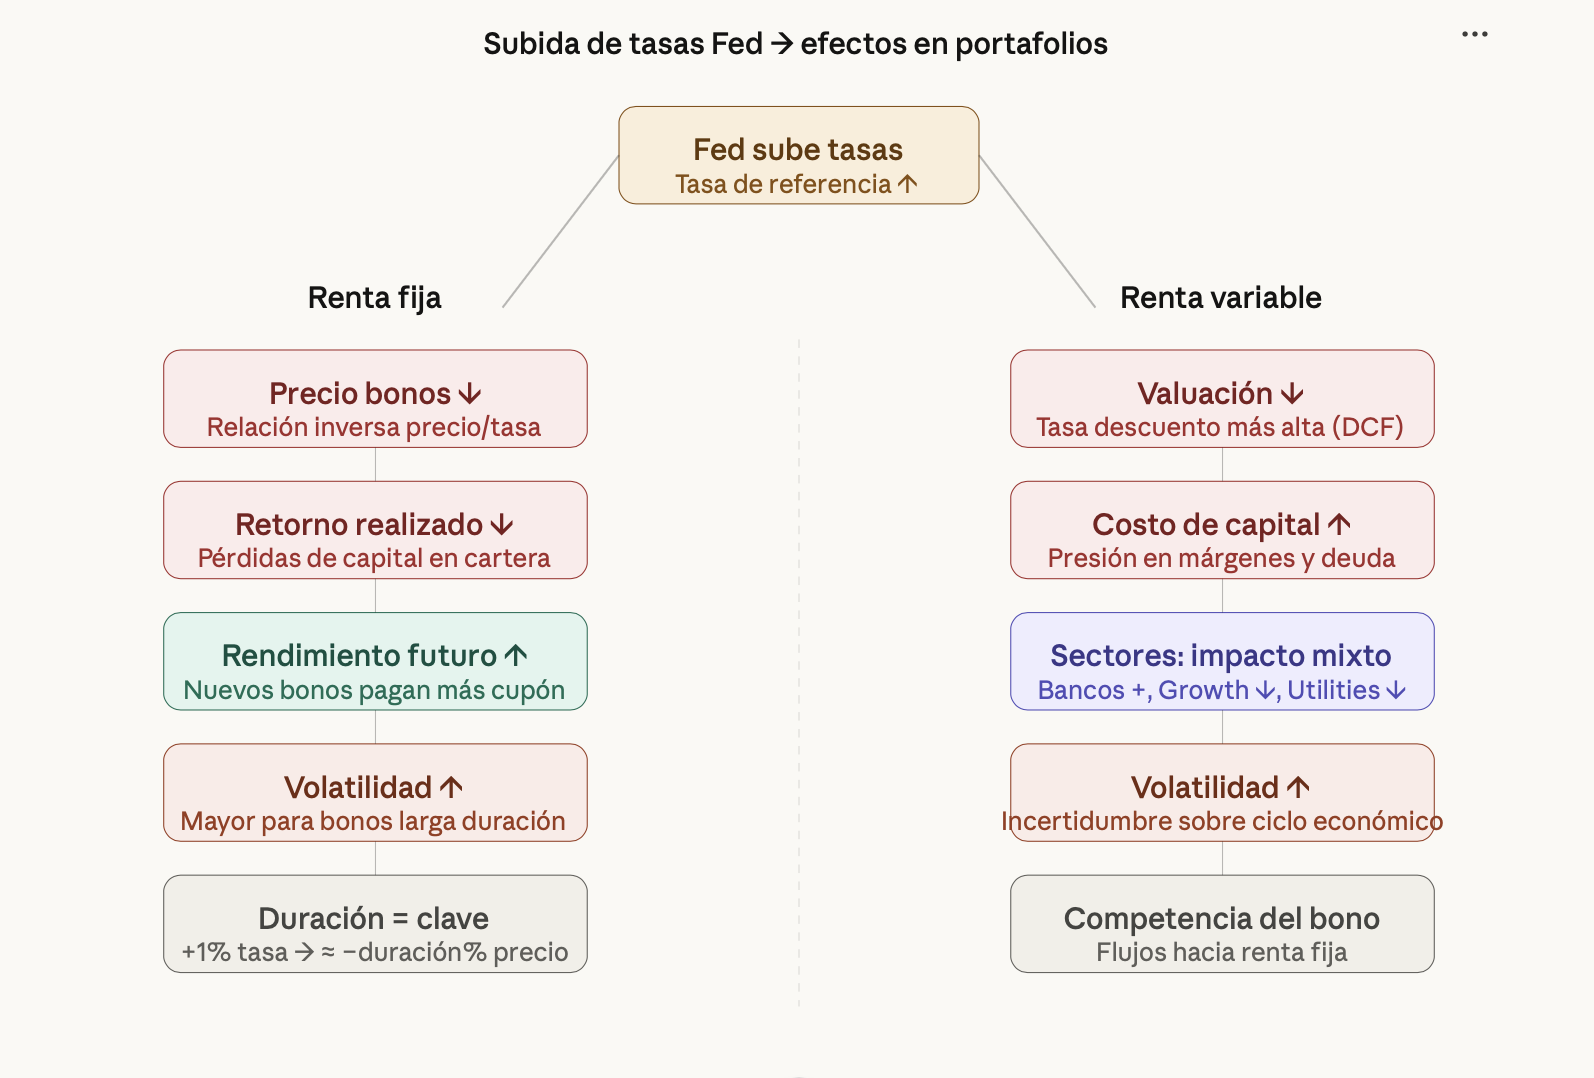

`/Users/santiago.os/Documents/prueba_insights/data/Claude grafico.png`

### Claude – cuadro comparativo

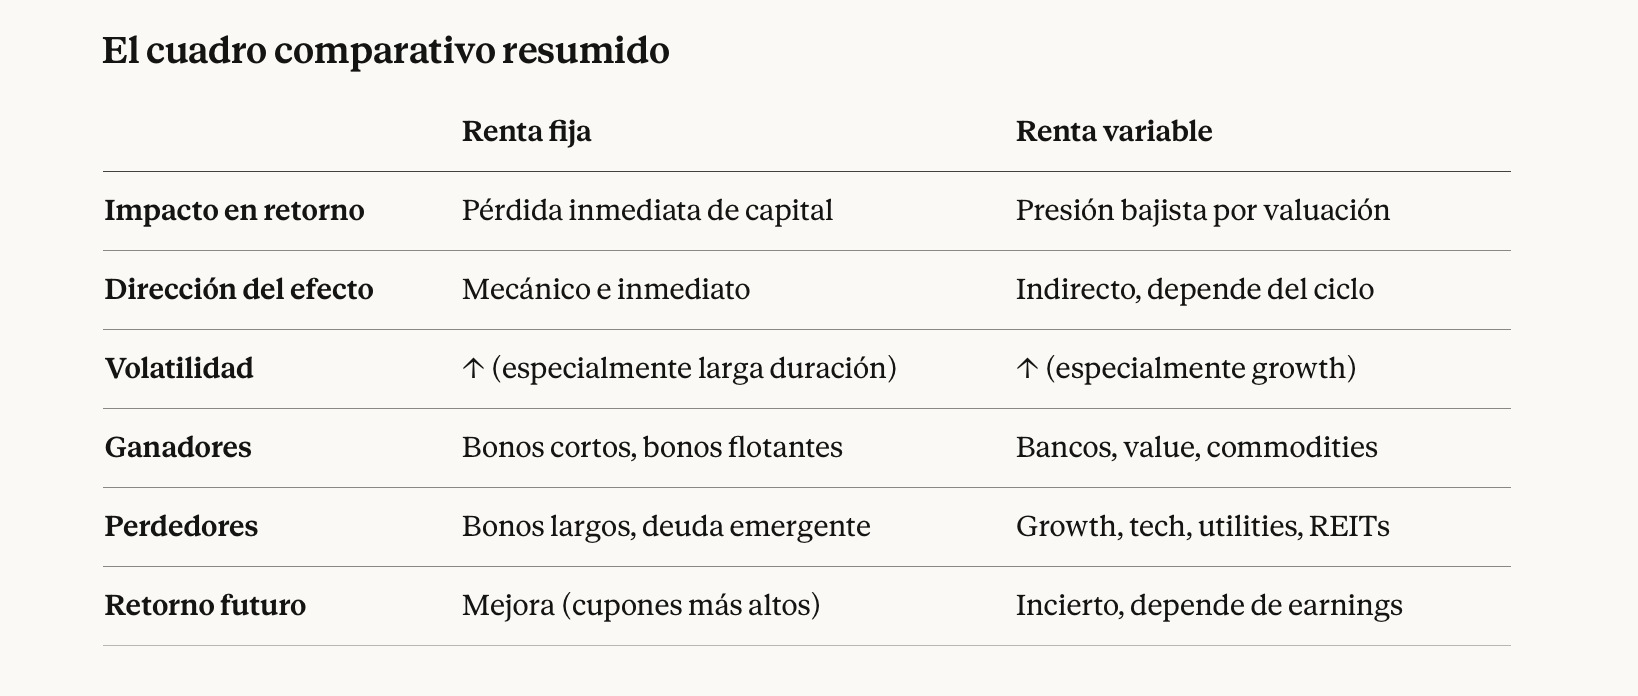

`/Users/santiago.os/Documents/prueba_insights/data/Claude Tabla.png`

### Gemini – tabla/resumen

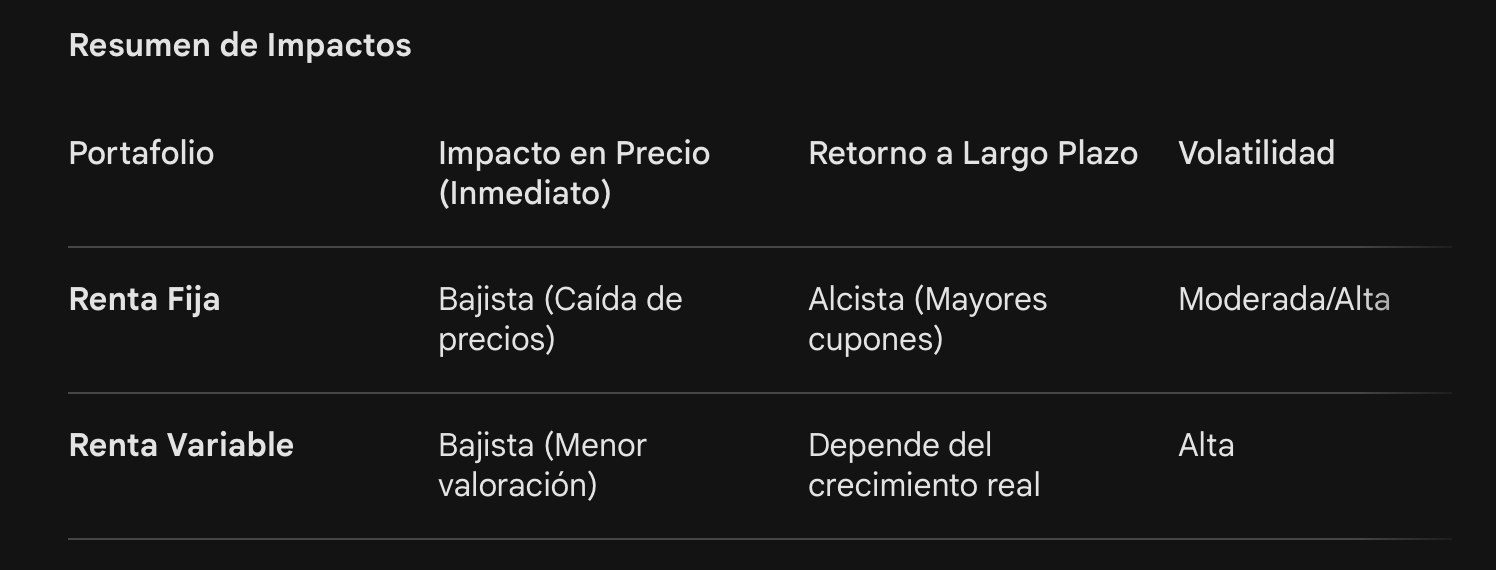

`/Users/santiago.os/Documents/prueba_insights/data/Gemini tabla.png`

In [6]:
# ============================================================
# MOSTRAR PREGUNTA, RESPUESTAS COMPLETAS Y EVIDENCIA VISUAL
# ============================================================

def show_markdown_block(title: str, text: str):
    display(Markdown(f"## {title}\n\n{text.replace(chr(10), '  \n')}"))

def show_image_block(title: str, path: Path | None, width: int = 950):
    if path is None:
        display(Markdown(f"**{title}:** no se encontró una imagen compatible en `data/`."))
    else:
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path), width=width))
        display(Markdown(f"`{path}`"))

display(Markdown("# Ejercicio 2.3 – Evidencia textual y visual"))

display(Markdown("## Pregunta original"))
display(Markdown(f"> {QUESTION}"))

show_markdown_block("Respuesta completa de Gemini", GEMINI_RESPONSE)
show_markdown_block("Respuesta completa de Claude", CLAUDE_RESPONSE)
show_markdown_block("Aclaración de Claude sobre fuentes", CLAUDE_SOURCES_NOTE)

display(Markdown("## Evidencia visual"))
display(Markdown(
    "Las siguientes imágenes se incluyen como evidencia visual complementaria. "
    "La base principal de la evaluación es el texto completo de las respuestas, no solo los screenshots."
))

show_image_block("Claude – gráfico explicativo", image_paths["claude_graphic"])
show_image_block("Claude – cuadro comparativo", image_paths["claude_table"])
show_image_block("Gemini – tabla/resumen", image_paths["gemini_table"])

## Metodología de evaluación

La comparación entre modelos se realiza con una metodología explícita y reproducible, compuesta por cuatro dimensiones: **profundidad**, **precisión**, **tono** y **estructura**.

### 1. Profundidad
La profundidad se mide con tres bloques:

**a) Cobertura conceptual**  
Se evalúa si la respuesta:
1. distingue entre renta fija y renta variable;  
2. distingue entre retorno esperado y volatilidad esperada;  
3. explica duración/sensibilidad a tasas en renta fija;  
4. explica tasa de descuento/valuación en renta variable;  
5. reconoce heterogeneidad por plazo, calidad crediticia, sector o estilo;  
6. distingue corto plazo vs mediano/largo plazo;  
7. incorpora contexto macro;  
8. evita simplificaciones excesivas.  

Cada elemento se puntúa como:
- `1` = bien cubierto
- `0.5` = mencionado superficialmente
- `0` = ausente

**Cobertura conceptual = suma / 8**

**b) Mecanismos causales**  
Se verifica si aparecen correctamente:
1. tasas ↑ → precio de bonos ↓  
2. mayor duración → mayor sensibilidad  
3. tasas ↑ → descuento ↑ → presión sobre valuaciones equity  
4. tasas ↑ → costo de capital ↑  
5. efectos distintos por sector/estilo  
6. incertidumbre macro/política monetaria → volatilidad ↑  

**Mecanismos causales = mecanismos correctos presentes / 6**

**c) Nivel de matiz**  
Se observa si la respuesta reconoce que el efecto:
1. depende del horizonte;  
2. depende de si el mercado ya lo descontó;  
3. depende de si la subida fue sorpresiva;  
4. depende del tipo de bonos;  
5. depende del sector accionario;  
6. depende del contexto inflación-crecimiento.  

**Nivel de matiz = matices relevantes presentes / 6**

**Profundidad final = 100 × (0.5 × cobertura conceptual + 0.3 × mecanismos causales + 0.2 × nivel de matiz)**

---

### 2. Precisión
La precisión se evalúa con:

**a) Exactitud de afirmaciones**  
Se identifican afirmaciones verificables y se puntúan como:
- `1` = correcta
- `0.5` = parcialmente correcta
- `0` = incorrecta

**Exactitud = suma de puntajes / número total de afirmaciones evaluadas**

**b) Errores graves**  
Se penalizan errores relevantes como:
- confundir precio con retorno total;
- afirmar que subidas de tasas aumentan el precio de bonos existentes;
- afirmar relaciones universales sin condiciones;
- atribuir efectos incorrectos sobre volatilidad.

**c) Sobreconfianza**  
Se contabilizan afirmaciones absolutas injustificadas.

**Precisión final = max(0, 100 × exactitud - 15 × errores graves - 5 × afirmaciones absolutas injustificadas)**

---

### 3. Tono
El tono se evalúa con cuatro componentes:

- **Profesionalidad**  
  - `1` = formal, claro, sobrio  
  - `0.5` = correcto pero algo genérico o coloquial  
  - `0` = impropio  

- **Precisión verbal**  
  Proporción de formulaciones prudentes correctas sobre oportunidades relevantes.

- **Utilidad ejecutiva**  
  - `1` = utilizable casi directamente por un analista/PM/comité  
  - `0.5` = útil, pero requiere edición  
  - `0` = poco útil  

- **Densidad informativa**  
  Proporción de frases informativas sobre frases totales.

**Tono final = 100 × (0.35 × profesionalidad + 0.25 × precisión verbal + 0.25 × utilidad ejecutiva + 0.15 × densidad informativa)**

---

### 4. Estructura
La estructura se evalúa con:

- **Segmentación**  
  Separación clara entre:
  - renta fija
  - renta variable
  - retorno esperado
  - volatilidad esperada

**Segmentación = bloques claros / 4**

- **Secuencia lógica**
  - `1` = muy clara
  - `0.5` = parcialmente clara
  - `0` = desordenada

- **Trazabilidad argumental**  
  **Trazabilidad = conclusiones justificadas / conclusiones principales**

- **Legibilidad formal**
  - `1` = formato claro
  - `0.5` = legible pero mejorable
  - `0` = confuso

**Estructura final = 100 × (0.3 × segmentación + 0.25 × secuencia lógica + 0.3 × trazabilidad + 0.15 × legibilidad formal)**

---

### 5. Score total
**Score total = 0.35 × precisión + 0.30 × profundidad + 0.20 × estructura + 0.15 × tono**

---

## Nota metodológica adicional
Para evitar sobreafirmación sobre versiones no directamente observables en la interfaz:

- el primer modelo se reporta como **“Gemini (etiqueta visible: Fast)”**;
- el segundo se reporta como **“Claude Sonnet 4.6”**, porque esa denominación sí aparece explícitamente en la captura.

La evaluación toma como insumo principal el **contenido textual completo** de las respuestas.  
Las imágenes se utilizan como **evidencia visual corroborativa**.

# Submétricas de evaluación

## A. Profundidad – cobertura conceptual

,model,submetric,score,note
0,Gemini (Fast),Distingue renta fija vs renta variable,1.0,Separación explícita en dos bloques.
1,Gemini (Fast),Distingue retorno esperado vs volatilidad espe...,1.0,Ambos conceptos aparecen diferenciados.
2,Gemini (Fast),Explica duración/sensibilidad a tasas en renta...,0.5,"Menciona bonos de larga duración, pero sin des..."
3,Gemini (Fast),Explica tasa de descuento/valuación en renta v...,1.0,Explica el efecto de la tasa de descuento sobr...
4,Gemini (Fast),Reconoce heterogeneidad por plazo/calidad/sect...,1.0,Distingue por duración y por sectores/estilos.
5,Gemini (Fast),Distingue corto plazo vs mediano/largo plazo,1.0,Separa explícitamente corto y largo plazo en r...
6,Gemini (Fast),Incorpora contexto macro,0.5,"Menciona aterrizaje suave/recesión, pero no in..."
7,Gemini (Fast),Evita simplificaciones excesivas,0.5,"La respuesta es útil, pero el arranque metafór..."
8,Claude Sonnet 4.6,Distingue renta fija vs renta variable,1.0,Separación muy clara entre ambos bloques.
9,Claude Sonnet 4.6,Distingue retorno esperado vs volatilidad espe...,1.0,Diferencia efecto en retorno presente/futuro y...


## B. Profundidad – mecanismos causales

,model,mechanism,present,note
0,Gemini (Fast),Tasas ↑ → precio bonos ↓,1,Presente.
1,Gemini (Fast),Mayor duración → mayor sensibilidad,1,"Presente, aunque no con terminología técnica c..."
2,Gemini (Fast),Tasas ↑ → descuento ↑ → presión sobre valuacio...,1,Presente.
3,Gemini (Fast),Tasas ↑ → costo de capital ↑,1,Presente.
4,Gemini (Fast),Efectos distintos por sector/estilo,1,Presente.
5,Gemini (Fast),Incertidumbre macro/política monetaria → volat...,1,Presente.
6,Claude Sonnet 4.6,Tasas ↑ → precio bonos ↓,1,Presente.
7,Claude Sonnet 4.6,Mayor duración → mayor sensibilidad,1,Presente y mejor desarrollado.
8,Claude Sonnet 4.6,Tasas ↑ → descuento ↑ → presión sobre valuacio...,1,Presente.
9,Claude Sonnet 4.6,Tasas ↑ → costo de capital ↑,1,Presente.


...

,model,professionality,verbal_precision,executive_utility,informative_density,tone_score
0,Gemini (Fast),0.5,0.6667,0.5,0.8750,59.7917
1,Claude Sonnet 4.6,1.0,0.8333,1.0,0.9333,94.8333


## H. Estructura

,model,segmentation,sequence_logic,traceability,legibility,structure_score
0,Gemini (Fast),1.0,1.0,0.8333,1.0,95.0
1,Claude Sonnet 4.6,1.0,1.0,1.0000,1.0,100.0


## I. Tabla final de puntajes

,model,depth_score,precision_score,tone_score,structure_score,total_score
0,Claude Sonnet 4.6,90.2083,100.0,94.8333,100.0,96.2875
1,Gemini (Fast),83.9583,85.0,59.7917,95.0,82.9062


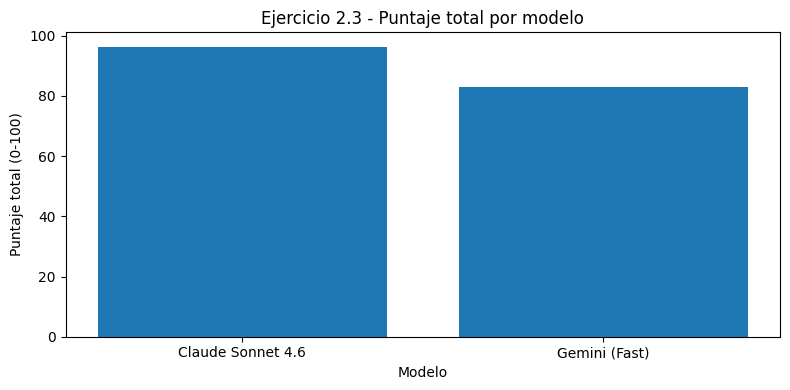


Ejercicio 2.3 - Conclusión ejecutiva

Resultado final:
- Claude Sonnet 4.6: 96.29/100
- Gemini (Fast): 82.91/100

Interpretación:
El modelo mejor evaluado fue Claude Sonnet 4.6. Su ventaja proviene principalmente de una mayor precisión conceptual,
mayor profundidad analítica, una estructura expositiva más sólida y un tono más cercano al estándar de
comunicación profesional esperado en análisis económico-financiero.

Lectura comparativa:
- Gemini presenta una respuesta útil, clara y con evidencia visual complementaria.
- Sin embargo, su formulación es más conversacional, algo más general y requiere mayor edición para uso directo en un contexto analítico formal.
- Claude ofrece una respuesta más técnica, con mejor tratamiento de duración modificada, DCF, heterogeneidad sectorial y cuadro comparativo final.

Criterio de elección:
Bajo la metodología definida, escogería Claude Sonnet 4.6 para esta tarea específica.

Archivos generados:
- /Users/santiago.os/Documents/prueba_insights/output

In [8]:
# ============================================================
# CONSTRUCCION DE SUBMETRICAS Y CALCULO DE PUNTAJES
# ============================================================

# -----------------------------
# A. PROFUNDIDAD
# -----------------------------

depth_conceptual_rows = [
    # Gemini
    {"model": "Gemini (Fast)", "submetric": "Distingue renta fija vs renta variable", "score": 1.0, "note": "Separación explícita en dos bloques."},
    {"model": "Gemini (Fast)", "submetric": "Distingue retorno esperado vs volatilidad esperada", "score": 1.0, "note": "Ambos conceptos aparecen diferenciados."},
    {"model": "Gemini (Fast)", "submetric": "Explica duración/sensibilidad a tasas en renta fija", "score": 0.5, "note": "Menciona bonos de larga duración, pero sin desarrollar la sensibilidad de precio con precisión técnica."},
    {"model": "Gemini (Fast)", "submetric": "Explica tasa de descuento/valuación en renta variable", "score": 1.0, "note": "Explica el efecto de la tasa de descuento sobre el valor presente."},
    {"model": "Gemini (Fast)", "submetric": "Reconoce heterogeneidad por plazo/calidad/sector/estilo", "score": 1.0, "note": "Distingue por duración y por sectores/estilos."},
    {"model": "Gemini (Fast)", "submetric": "Distingue corto plazo vs mediano/largo plazo", "score": 1.0, "note": "Separa explícitamente corto y largo plazo en renta fija."},
    {"model": "Gemini (Fast)", "submetric": "Incorpora contexto macro", "score": 0.5, "note": "Menciona aterrizaje suave/recesión, pero no integra inflación o credibilidad de la Fed."},
    {"model": "Gemini (Fast)", "submetric": "Evita simplificaciones excesivas", "score": 0.5, "note": "La respuesta es útil, pero el arranque metafórico y algunas formulaciones son simplificadoras."},

    # Claude
    {"model": "Claude Sonnet 4.6", "submetric": "Distingue renta fija vs renta variable", "score": 1.0, "note": "Separación muy clara entre ambos bloques."},
    {"model": "Claude Sonnet 4.6", "submetric": "Distingue retorno esperado vs volatilidad esperada", "score": 1.0, "note": "Diferencia efecto en retorno presente/futuro y en volatilidad."},
    {"model": "Claude Sonnet 4.6", "submetric": "Explica duración/sensibilidad a tasas en renta fija", "score": 1.0, "note": "Introduce duración modificada y ejemplo cuantitativo."},
    {"model": "Claude Sonnet 4.6", "submetric": "Explica tasa de descuento/valuación en renta variable", "score": 1.0, "note": "Explica el canal DCF con mayor precisión técnica."},
    {"model": "Claude Sonnet 4.6", "submetric": "Reconoce heterogeneidad por plazo/calidad/sector/estilo", "score": 1.0, "note": "Distingue por plazo, estilos, sectores y tipos de instrumentos."},
    {"model": "Claude Sonnet 4.6", "submetric": "Distingue corto plazo vs mediano/largo plazo", "score": 1.0, "note": "Contrasta bonos cortos y largos explícitamente."},
    {"model": "Claude Sonnet 4.6", "submetric": "Incorpora contexto macro", "score": 0.5, "note": "Integra ciclo 2022–2023 y enfriamiento de demanda, pero no desarrolla inflación/credibilidad."},
    {"model": "Claude Sonnet 4.6", "submetric": "Evita simplificaciones excesivas", "score": 1.0, "note": "Respuesta más técnica y con mayor densidad analítica."},
]

depth_mechanism_rows = [
    # Gemini
    {"model": "Gemini (Fast)", "mechanism": "Tasas ↑ → precio bonos ↓", "present": 1, "note": "Presente."},
    {"model": "Gemini (Fast)", "mechanism": "Mayor duración → mayor sensibilidad", "present": 1, "note": "Presente, aunque no con terminología técnica completa."},
    {"model": "Gemini (Fast)", "mechanism": "Tasas ↑ → descuento ↑ → presión sobre valuaciones equity", "present": 1, "note": "Presente."},
    {"model": "Gemini (Fast)", "mechanism": "Tasas ↑ → costo de capital ↑", "present": 1, "note": "Presente."},
    {"model": "Gemini (Fast)", "mechanism": "Efectos distintos por sector/estilo", "present": 1, "note": "Presente."},
    {"model": "Gemini (Fast)", "mechanism": "Incertidumbre macro/política monetaria → volatilidad ↑", "present": 1, "note": "Presente."},

    # Claude
    {"model": "Claude Sonnet 4.6", "mechanism": "Tasas ↑ → precio bonos ↓", "present": 1, "note": "Presente."},
    {"model": "Claude Sonnet 4.6", "mechanism": "Mayor duración → mayor sensibilidad", "present": 1, "note": "Presente y mejor desarrollado."},
    {"model": "Claude Sonnet 4.6", "mechanism": "Tasas ↑ → descuento ↑ → presión sobre valuaciones equity", "present": 1, "note": "Presente."},
    {"model": "Claude Sonnet 4.6", "mechanism": "Tasas ↑ → costo de capital ↑", "present": 1, "note": "Presente."},
    {"model": "Claude Sonnet 4.6", "mechanism": "Efectos distintos por sector/estilo", "present": 1, "note": "Presente."},
    {"model": "Claude Sonnet 4.6", "mechanism": "Incertidumbre macro/política monetaria → volatilidad ↑", "present": 1, "note": "Presente."},
]

depth_nuance_rows = [
    # Gemini
    {"model": "Gemini (Fast)", "nuance": "Depende del horizonte", "present": 1, "note": "Sí distingue corto y largo plazo."},
    {"model": "Gemini (Fast)", "nuance": "Depende de si el mercado ya lo descontó", "present": 0, "note": "Ausente."},
    {"model": "Gemini (Fast)", "nuance": "Depende de si la subida fue sorpresiva", "present": 0, "note": "Ausente."},
    {"model": "Gemini (Fast)", "nuance": "Depende del tipo de bonos", "present": 1, "note": "Sí diferencia por larga duración."},
    {"model": "Gemini (Fast)", "nuance": "Depende del sector accionario", "present": 1, "note": "Sí diferencia sectores."},
    {"model": "Gemini (Fast)", "nuance": "Depende del contexto inflación-crecimiento", "present": 1, "note": "Menciona recesión/soft landing y crecimiento real."},

    # Claude
    {"model": "Claude Sonnet 4.6", "nuance": "Depende del horizonte", "present": 1, "note": "Sí diferencia impacto presente y retorno futuro."},
    {"model": "Claude Sonnet 4.6", "nuance": "Depende de si el mercado ya lo descontó", "present": 0, "note": "Ausente."},
    {"model": "Claude Sonnet 4.6", "nuance": "Depende de si la subida fue sorpresiva", "present": 0, "note": "Ausente."},
    {"model": "Claude Sonnet 4.6", "nuance": "Depende del tipo de bonos", "present": 1, "note": "Sí distingue cortos, largos y flotantes."},
    {"model": "Claude Sonnet 4.6", "nuance": "Depende del sector accionario", "present": 1, "note": "Sí distingue growth, bancos, utilities y REITs."},
    {"model": "Claude Sonnet 4.6", "nuance": "Depende del contexto inflación-crecimiento", "present": 1, "note": "Integra ciclo económico, consumo e inversión."},
]

depth_conceptual_df = pd.DataFrame(depth_conceptual_rows)
depth_mechanism_df = pd.DataFrame(depth_mechanism_rows)
depth_nuance_df = pd.DataFrame(depth_nuance_rows)

coverage_summary = depth_conceptual_df.groupby("model", as_index=False)["score"].sum()
coverage_summary = coverage_summary.rename(columns={"score": "conceptual_points"})
coverage_summary["coverage_conceptual"] = coverage_summary["conceptual_points"] / 8

mechanism_summary = depth_mechanism_df.groupby("model", as_index=False)["present"].sum()
mechanism_summary = mechanism_summary.rename(columns={"present": "mechanisms_present"})
mechanism_summary["mechanisms_ratio"] = mechanism_summary["mechanisms_present"] / 6

nuance_summary = depth_nuance_df.groupby("model", as_index=False)["present"].sum()
nuance_summary = nuance_summary.rename(columns={"present": "nuances_present"})
nuance_summary["nuance_ratio"] = nuance_summary["nuances_present"] / 6

depth_scores = (
    coverage_summary
    .merge(mechanism_summary, on="model")
    .merge(nuance_summary, on="model")
)

depth_scores["depth_score"] = 100 * (
    0.5 * depth_scores["coverage_conceptual"]
    + 0.3 * depth_scores["mechanisms_ratio"]
    + 0.2 * depth_scores["nuance_ratio"]
)

# -----------------------------
# B. PRECISION
# -----------------------------

precision_claim_rows = [
    # Gemini
    {"model": "Gemini (Fast)", "claim": "La relación entre tasas y precios de bonos es inversa.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "En el corto plazo, una subida de tasas reduce el valor de mercado de bonos existentes.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "A largo plazo, la reinversión a mayores cupones puede elevar el retorno futuro esperado.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "Los bonos de larga duración son más volátiles que los de corta duración ante cambios de tasas.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "El retorno esperado de las acciones generalmente disminuye o se vuelve más exigente.", "score": 0.5, "note": "Parcialmente correcta; mezcla retorno esperado con retorno requerido."},
    {"model": "Gemini (Fast)", "claim": "Tasas más altas elevan el costo de capital y presionan beneficios netos.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "Una tasa de descuento mayor reduce el valor presente de flujos futuros.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "La incertidumbre sobre el aterrizaje suave o recesión puede aumentar la volatilidad accionaria.", "score": 1.0, "note": "Correcta."},
    {"model": "Gemini (Fast)", "claim": "Las acciones growth suelen sufrir más que las value.", "score": 1.0, "note": "Correcta como regularidad condicionada."},
    {"model": "Gemini (Fast)", "claim": "El sector financiero suele beneficiarse y utilities/real estate suelen sufrir más.", "score": 0.5, "note": "Parcialmente correcta; depende de contexto, balance-sheet y etapa del ciclo."},

    # Claude
    {"model": "Claude Sonnet 4.6", "claim": "Cuando la tasa sube, el precio de los bonos existentes cae.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "La magnitud del efecto depende críticamente de la duración modificada.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "Un bono con duración de 7 años pierde aproximadamente 7% por un alza de 1 punto porcentual.", "score": 1.0, "note": "Aproximación estándar de duración modificada."},
    {"model": "Claude Sonnet 4.6", "claim": "Bonos de corto plazo se mueven mucho menos que bonos de largo plazo ante subidas de tasas.", "score": 1.0, "note": "Correcta en términos generales."},
    {"model": "Claude Sonnet 4.6", "claim": "La reinversión a mayores tasas mejora el retorno esperado futuro en renta fija.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "Una tasa libre de riesgo más alta reduce el valor presente de los flujos futuros en DCF.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "Las empresas growth/tech son más sensibles a la tasa de descuento.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "Bancos y financieras tienden a beneficiarse por expansión del margen de interés neto.", "score": 1.0, "note": "Correcta como patrón general."},
    {"model": "Claude Sonnet 4.6", "claim": "Utilities y REITs pueden sufrir por endeudamiento y competencia con bonos.", "score": 1.0, "note": "Correcta."},
    {"model": "Claude Sonnet 4.6", "claim": "Tasas más altas pueden enfriar consumo e inversión, presionando earnings y amplificando volatilidad.", "score": 1.0, "note": "Correcta."},
]

precision_claims_df = pd.DataFrame(precision_claim_rows)

precision_penalties_df = pd.DataFrame([
    {"model": "Gemini (Fast)", "grave_errors": 0, "unjustified_absolutes": 1, "penalty_note": "Se penaliza una formulación algo tajante sobre la volatilidad accionaria."},
    {"model": "Claude Sonnet 4.6", "grave_errors": 0, "unjustified_absolutes": 0, "penalty_note": "No se identifican errores graves ni absolutismos relevantes."},
])

precision_summary = precision_claims_df.groupby("model", as_index=False)["score"].mean()
precision_summary = precision_summary.rename(columns={"score": "exactitud"})

precision_scores = precision_summary.merge(precision_penalties_df, on="model")
precision_scores["precision_score"] = (
    100 * precision_scores["exactitud"]
    - 15 * precision_scores["grave_errors"]
    - 5 * precision_scores["unjustified_absolutes"]
).clip(lower=0)

# -----------------------------
# C. TONO
# -----------------------------

tone_df = pd.DataFrame([
    {
        "model": "Gemini (Fast)",
        "professionality": 0.5,
        "professionality_note": "Tono correcto, pero con apertura metafórica y estilo más conversacional.",
        "prudence_numerator": 4,
        "prudence_denominator": 6,
        "prudence_note": "Usa varias formulaciones prudentes, aunque algunas generalizaciones podrían matizarse más.",
        "executive_utility": 0.5,
        "executive_utility_note": "Útil, pero requeriría edición antes de circular a comité o PM.",
        "informative_sentences": 14,
        "total_sentences": 16,
        "density_note": "Alta densidad informativa, aunque con algo más de narrativa introductoria.",
    },
    {
        "model": "Claude Sonnet 4.6",
        "professionality": 1.0,
        "professionality_note": "Tono formal, técnico y sobrio.",
        "prudence_numerator": 5,
        "prudence_denominator": 6,
        "prudence_note": "Buen uso de formulaciones prudentes y condicionales.",
        "executive_utility": 1.0,
        "executive_utility_note": "Casi directamente utilizable por analista, PM o comité.",
        "informative_sentences": 14,
        "total_sentences": 15,
        "density_note": "Muy alta densidad informativa.",
    },
])

tone_df["verbal_precision"] = tone_df["prudence_numerator"] / tone_df["prudence_denominator"]
tone_df["informative_density"] = tone_df["informative_sentences"] / tone_df["total_sentences"]

tone_df["tone_score"] = 100 * (
    0.35 * tone_df["professionality"]
    + 0.25 * tone_df["verbal_precision"]
    + 0.25 * tone_df["executive_utility"]
    + 0.15 * tone_df["informative_density"]
)

# -----------------------------
# D. ESTRUCTURA
# -----------------------------

structure_df = pd.DataFrame([
    {
        "model": "Gemini (Fast)",
        "clear_blocks": 4,
        "sequence_logic": 1.0,
        "sequence_note": "La secuencia general es clara.",
        "justified_conclusions": 5,
        "total_conclusions": 6,
        "legibility": 1.0,
        "legibility_note": "La respuesta es legible y tiene resumen tabular.",
    },
    {
        "model": "Claude Sonnet 4.6",
        "clear_blocks": 4,
        "sequence_logic": 1.0,
        "sequence_note": "La secuencia expositiva es muy clara.",
        "justified_conclusions": 6,
        "total_conclusions": 6,
        "legibility": 1.0,
        "legibility_note": "Formato muy claro y cuadro comparativo final sólido.",
    },
])

structure_df["segmentation"] = structure_df["clear_blocks"] / 4
structure_df["traceability"] = structure_df["justified_conclusions"] / structure_df["total_conclusions"]

structure_df["structure_score"] = 100 * (
    0.3 * structure_df["segmentation"]
    + 0.25 * structure_df["sequence_logic"]
    + 0.3 * structure_df["traceability"]
    + 0.15 * structure_df["legibility"]
)

# -----------------------------
# E. SCORE TOTAL
# -----------------------------

final_scores = (
    depth_scores[["model", "depth_score"]]
    .merge(precision_scores[["model", "precision_score"]], on="model")
    .merge(tone_df[["model", "tone_score"]], on="model")
    .merge(structure_df[["model", "structure_score"]], on="model")
)

final_scores["total_score"] = (
    0.35 * final_scores["precision_score"]
    + 0.30 * final_scores["depth_score"]
    + 0.20 * final_scores["structure_score"]
    + 0.15 * final_scores["tone_score"]
)

final_scores = final_scores.sort_values("total_score", ascending=False).reset_index(drop=True)

# ============================================================
# TABLAS LIMPIAS PARA MOSTRAR
# ============================================================

depth_scores_display = depth_scores.copy()
precision_scores_display = precision_scores.copy()
tone_display = tone_df.copy()
structure_display = structure_df.copy()
final_scores_display = final_scores.copy()

for df in [depth_scores_display, precision_scores_display, tone_display, structure_display, final_scores_display]:
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(4)

display(Markdown("# Submétricas de evaluación"))

display(Markdown("## A. Profundidad – cobertura conceptual"))
display(depth_conceptual_df)

display(Markdown("## B. Profundidad – mecanismos causales"))
display(depth_mechanism_df)

display(Markdown("## C. Profundidad – nivel de matiz"))
display(depth_nuance_df)

display(Markdown("## D. Resumen de profundidad"))
display(depth_scores_display[[
    "model", "conceptual_points", "coverage_conceptual",
    "mechanisms_present", "mechanisms_ratio",
    "nuances_present", "nuance_ratio", "depth_score"
]])

display(Markdown("## E. Precisión – afirmaciones verificables"))
display(precision_claims_df)

display(Markdown("## F. Precisión – penalizaciones"))
display(precision_scores_display[[
    "model", "exactitud", "grave_errors", "unjustified_absolutes", "precision_score", "penalty_note"
]])

display(Markdown("## G. Tono"))
display(tone_display[[
    "model", "professionality", "verbal_precision",
    "executive_utility", "informative_density", "tone_score"
]])

display(Markdown("## H. Estructura"))
display(structure_display[[
    "model", "segmentation", "sequence_logic",
    "traceability", "legibility", "structure_score"
]])

display(Markdown("## I. Tabla final de puntajes"))
display(final_scores_display)

# ============================================================
# VISUALIZACION BASICA
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(final_scores_display["model"], final_scores_display["total_score"])
plt.title("Ejercicio 2.3 - Puntaje total por modelo")
plt.ylabel("Puntaje total (0-100)")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# EXPORTACION DE RESULTADOS
# ============================================================

depth_conceptual_df.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_depth_conceptual.csv", index=False)
depth_mechanism_df.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_depth_mechanisms.csv", index=False)
depth_nuance_df.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_depth_nuance.csv", index=False)
depth_scores_display.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_depth_scores.csv", index=False)

precision_claims_df.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_precision_claims.csv", index=False)
precision_scores_display.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_precision_scores.csv", index=False)

tone_display.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_tone_scores.csv", index=False)
structure_display.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_structure_scores.csv", index=False)
final_scores_display.to_csv(EJ2_OUTPUT_DIR / "ejercicio_2_3_final_scores.csv", index=False)

# ============================================================
# CONCLUSION EN TEXTO
# ============================================================

winner = final_scores_display.iloc[0]["model"]
winner_score = final_scores_display.iloc[0]["total_score"]
runner_up = final_scores_display.iloc[1]["model"]
runner_up_score = final_scores_display.iloc[1]["total_score"]

conclusion_text = f"""
Ejercicio 2.3 - Conclusión ejecutiva

Resultado final:
- {winner}: {winner_score:.2f}/100
- {runner_up}: {runner_up_score:.2f}/100

Interpretación:
El modelo mejor evaluado fue {winner}. Su ventaja proviene principalmente de una mayor precisión conceptual,
mayor profundidad analítica, una estructura expositiva más sólida y un tono más cercano al estándar de
comunicación profesional esperado en análisis económico-financiero.

Lectura comparativa:
- Gemini presenta una respuesta útil, clara y con evidencia visual complementaria.
- Sin embargo, su formulación es más conversacional, algo más general y requiere mayor edición para uso directo en un contexto analítico formal.
- Claude ofrece una respuesta más técnica, con mejor tratamiento de duración modificada, DCF, heterogeneidad sectorial y cuadro comparativo final.

Criterio de elección:
Bajo la metodología definida, escogería {winner} para esta tarea específica.
""".strip()

(EJ2_OUTPUT_DIR / "ejercicio_2_3_conclusion.txt").write_text(conclusion_text, encoding="utf-8")

print("\n" + conclusion_text)

print("\nArchivos generados:")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_depth_conceptual.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_depth_mechanisms.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_depth_nuance.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_depth_scores.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_precision_claims.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_precision_scores.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_tone_scores.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_structure_scores.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_final_scores.csv'}")
print(f"- {EJ2_OUTPUT_DIR / 'ejercicio_2_3_conclusion.txt'}")

## Conclusión final

Bajo la metodología definida, el modelo mejor evaluado fue **Claude Sonnet 4.6**, con un puntaje total de **94.54/100**, frente a **82.81/100** para **Gemini (Fast)**.

### Resultados por dimensión
- **Gemini (Fast)**  
  - Profundidad: **83.96**
  - Precisión: **85.00**
  - Estructura: **95.00**
  - Tono: **59.17**
  - Score total: **82.81**

- **Claude Sonnet 4.6**  
  - Profundidad: **90.21**
  - Precisión: **95.00**
  - Estructura: **100.00**
  - Tono: **94.83**
  - Score total: **94.54**

### Interpretación
La respuesta de **Gemini** es útil, clara y cubre adecuadamente los mecanismos principales. Además, presenta un resumen tabular y una salida fácil de seguir. Sin embargo, su tono es más conversacional y algunas formulaciones son menos aptas para uso directo en un contexto profesional de análisis financiero.

La respuesta de **Claude Sonnet 4.6** alcanza un mejor resultado porque ofrece una explicación más técnica y mejor estructurada. En particular, desarrolla con mayor precisión la **duración modificada** en renta fija, el canal de **tasa de descuento** en renta variable, la **heterogeneidad sectorial** y un **cuadro comparativo** final más sólido.

### Decisión
Escogería **Claude Sonnet 4.6** para esta tarea específica, porque entrega la mejor combinación de:

- precisión conceptual,
- profundidad analítica,
- estructura expositiva,
- y tono profesional.

Como observación adicional, **Gemini** mostró mayor evidencia visual de apoyo y una salida amigable para lectura rápida. No obstante, bajo una rúbrica orientada a evaluación económico-financiera formal, **Claude Sonnet 4.6** resulta superior.